In [1]:
# import the required Python libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [2]:
from google.colab import files
Upload = files.upload()

data = pd.read_csv('airlines_flights_data.csv')
data.head()

Saving airlines_flights_data.csv to airlines_flights_data.csv


,index,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [28]:
len(data)

300153

In [31]:
data.shape[0]

300153

In [3]:
# Remove the 'index' column

data.drop( columns = 'index', inplace = True)

In [4]:
# Get some Info about the dataset

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   airline           300153 non-null  object 
 1   flight            300153 non-null  object 
 2   source_city       300153 non-null  object 
 3   departure_time    300153 non-null  object 
 4   stops             300153 non-null  object 
 5   arrival_time      300153 non-null  object 
 6   destination_city  300153 non-null  object 
 7   class             300153 non-null  object 
 8   duration          300153 non-null  float64
 9   days_left         300153 non-null  int64  
 10  price             300153 non-null  int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 25.2+ MB


In [5]:
# Get Statistical summary about the dataset

data.describe()

,duration,days_left,price
count,300153.000000,300153.000000,300153.000000
mean,12.221021,26.004751,20889.660523
std,7.191997,13.561004,22697.767366
min,0.830000,1.000000,1105.000000
25%,6.830000,15.000000,4783.000000
50%,11.250000,26.000000,7425.000000
75%,16.170000,38.000000,42521.000000
max,49.830000,49.000000,123071.000000


In [6]:
data[ data['duration'] == 49.830000 ]

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
193889,Air_India,AI-672,Chennai,Evening,two_or_more,Evening,Bangalore,Economy,49.83,2,23891
194359,Air_India,AI-672,Chennai,Evening,one,Evening,Bangalore,Economy,49.83,9,17538


In [7]:
data[ data['duration'] == 0.830000 ]

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
115869,Indigo,6E-357,Bangalore,Night,zero,Night,Chennai,Economy,0.83,6,3498
115943,Indigo,6E-357,Bangalore,Night,zero,Night,Chennai,Economy,0.83,7,3498
116010,Indigo,6E-357,Bangalore,Night,zero,Night,Chennai,Economy,0.83,8,3498
116081,Indigo,6E-357,Bangalore,Night,zero,Night,Chennai,Economy,0.83,9,3498
116163,Indigo,6E-357,Bangalore,Night,zero,Night,Chennai,Economy,0.83,10,3498
116236,Indigo,6E-357,Bangalore,Night,zero,Night,Chennai,Economy,0.83,11,3498
116322,Indigo,6E-357,Bangalore,Night,zero,Night,Chennai,Economy,0.83,12,3498
116411,Indigo,6E-357,Bangalore,Night,zero,Night,Chennai,Economy,0.83,13,3498
116496,Indigo,6E-357,Bangalore,Night,zero,Night,Chennai,Economy,0.83,14,3498
116656,Indigo,6E-357,Bangalore,Night,zero,Night,Chennai,Economy,0.83,16,1924


In [8]:
data [ data['price'] == 123071.000000 ]

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
261377,Vistara,UK-772,Kolkata,Morning,one,Night,Delhi,Business,13.5,3,123071


In [9]:
data [ data['price'] == 1105.000000 ]

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
203807,AirAsia,I5-517,Chennai,Morning,zero,Morning,Hyderabad,Economy,1.17,16,1105
203808,GO_FIRST,G8-505,Chennai,Evening,zero,Evening,Hyderabad,Economy,1.25,16,1105
203908,AirAsia,I5-517,Chennai,Morning,zero,Morning,Hyderabad,Economy,1.17,17,1105
203909,GO_FIRST,G8-505,Chennai,Evening,zero,Evening,Hyderabad,Economy,1.25,17,1105
204003,AirAsia,I5-517,Chennai,Morning,zero,Morning,Hyderabad,Economy,1.17,18,1105
...,...,...,...,...,...,...,...,...,...,...,...
206601,Indigo,6E-7261,Chennai,Morning,one,Evening,Hyderabad,Economy,7.92,49,1105
206602,Indigo,6E-611,Chennai,Evening,one,Late_Night,Hyderabad,Economy,8.25,49,1105
206603,Indigo,6E-581,Chennai,Morning,one,Evening,Hyderabad,Economy,9.17,49,1105
206604,Indigo,6E-7127,Chennai,Afternoon,one,Night,Hyderabad,Economy,9.50,49,1105


In [10]:
data.isnull().sum()            # check for the missing values in any column

,0
airline,0
flight,0
source_city,0
departure_time,0
stops,0
arrival_time,0
destination_city,0
class,0
duration,0
days_left,0


**Q.1. What are the airlines in the dataset, accompanied by their frequencies?**

In [11]:
# Checking how many Airlines are in the dataset

data['airline'].nunique()

6

In [12]:
# Showing the names of the Airlines in the dataset

data['airline'].unique()

array(['SpiceJet', 'AirAsia', 'Vistara', 'GO_FIRST', 'Indigo',
       'Air_India'], dtype=object)

In [13]:
# Showing all the Airlines with their frequencies

data['airline'].value_counts()

,count
airline,
Vistara,127859
Air_India,80892
Indigo,43120
GO_FIRST,23173
AirAsia,16098
SpiceJet,9011


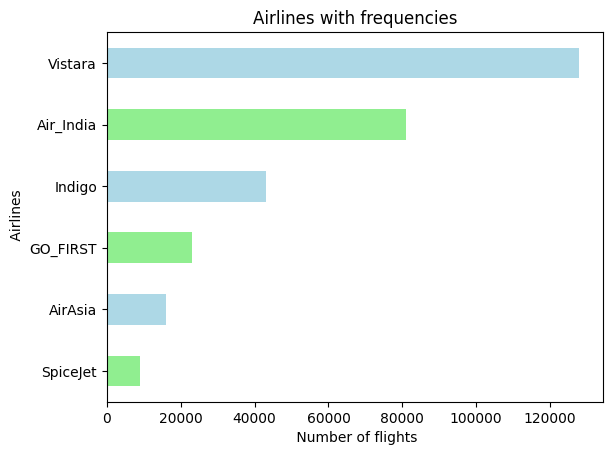

In [14]:
# Showing all the Airlines with their Number of Flights in Horizontal Bar Graph

data['airline'].value_counts(ascending=True).plot.barh( color = ['lightgreen', 'lightblue'])

plt.title("Airlines with frequencies")

plt.xlabel(" Number of flights")

plt.ylabel(" Airlines")

plt.show()

**Q.2. Show Bar Graphs representing the Departure Time & Arrival Time**

In [15]:
# Showing the Departure Time for the flights

data['departure_time'].value_counts()

,count
departure_time,
Morning,71146
Early_Morning,66790
Evening,65102
Night,48015
Afternoon,47794
Late_Night,1306


In [16]:
# Showing the Arrival Time for the flights

data['arrival_time'].value_counts()

,count
arrival_time,
Night,91538
Evening,78323
Morning,62735
Afternoon,38139
Early_Morning,15417
Late_Night,14001


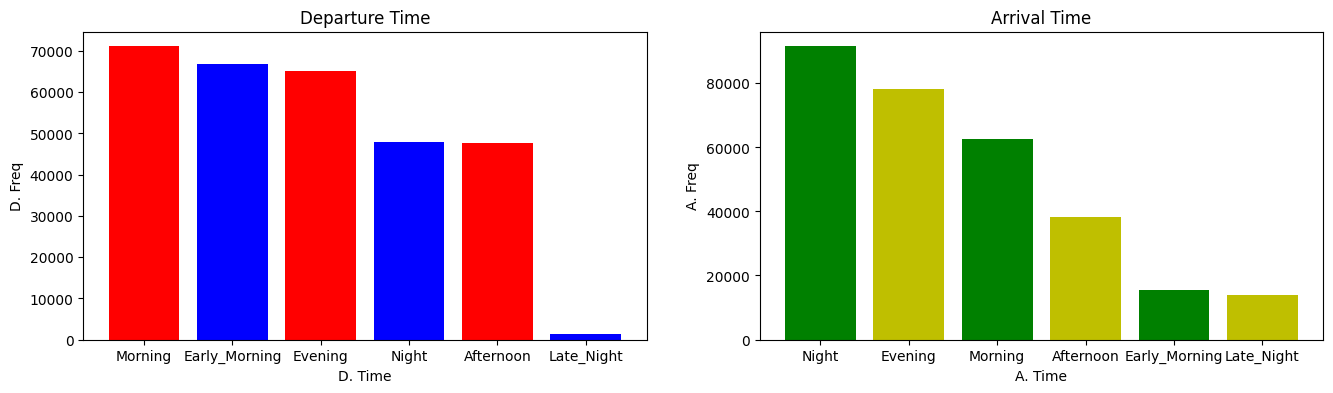

In [23]:
# Showing the Departure Time & Arrival Time for the flights with their counts

plt.figure(figsize = (16,4))

plt.subplot(1,2,1)

plt.bar( data['departure_time'].value_counts().index , data['departure_time'].value_counts().values, color = ['r', 'b'] )
plt.title("Departure Time")
plt.xlabel("D. Time")
plt.ylabel("D. Freq")

plt.subplot(1,2,2)

plt.bar( data['arrival_time'].value_counts().index, data['arrival_time'].value_counts().values, color = ['g', 'y'])
plt.title("Arrival Time")
plt.xlabel("A. Time")
plt.ylabel("A. Freq")

plt.show()

**Q.3. Show Bar Graphs representing the Source City & Destination City**

In [19]:
# Showing the Source City of the flights

data['source_city'].value_counts()

,count
source_city,
Delhi,61343
Mumbai,60896
Bangalore,52061
Kolkata,46347
Hyderabad,40806
Chennai,38700


In [20]:
# Showing the Destination City of the flights

data['destination_city'].value_counts()

,count
destination_city,
Mumbai,59097
Delhi,57360
Bangalore,51068
Kolkata,49534
Hyderabad,42726
Chennai,40368


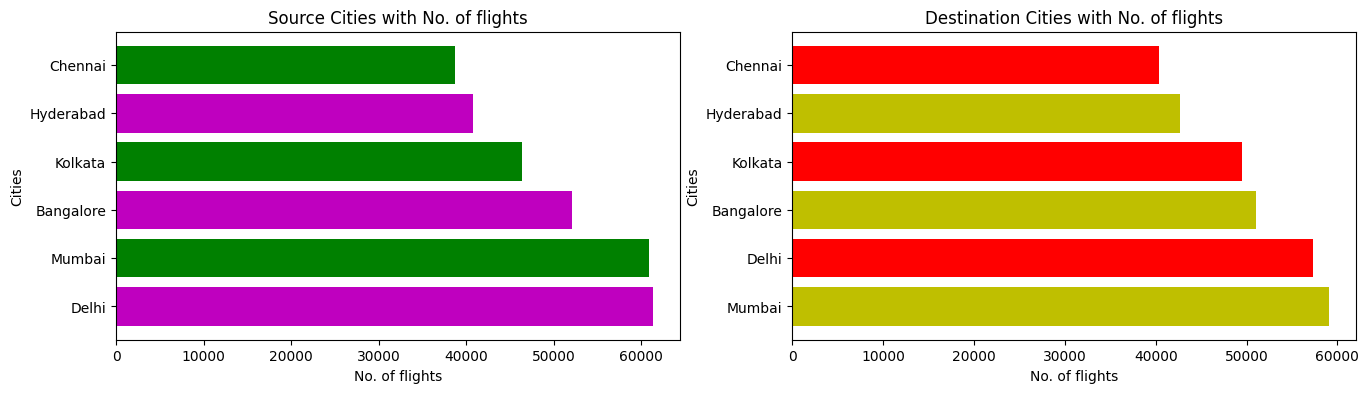

In [24]:
# Showing the Source City & Destination City for the flights with their counts

plt.figure( figsize= (16,4))

plt.subplot(1,2,1)

plt.barh( data['source_city'].value_counts().index , data['source_city'].value_counts().values, color = ['m', 'g'])
plt.title("Source Cities with No. of flights")
plt.ylabel("Cities")
plt.xlabel("No. of flights")

plt.subplot(1,2,2)

plt.barh( data['destination_city'].value_counts().index , data['destination_city'].value_counts().values, color = ['y', 'r'])
plt.title("Destination Cities with No. of flights")
plt.ylabel("Cities")
plt.xlabel("No. of flights")

plt.show()

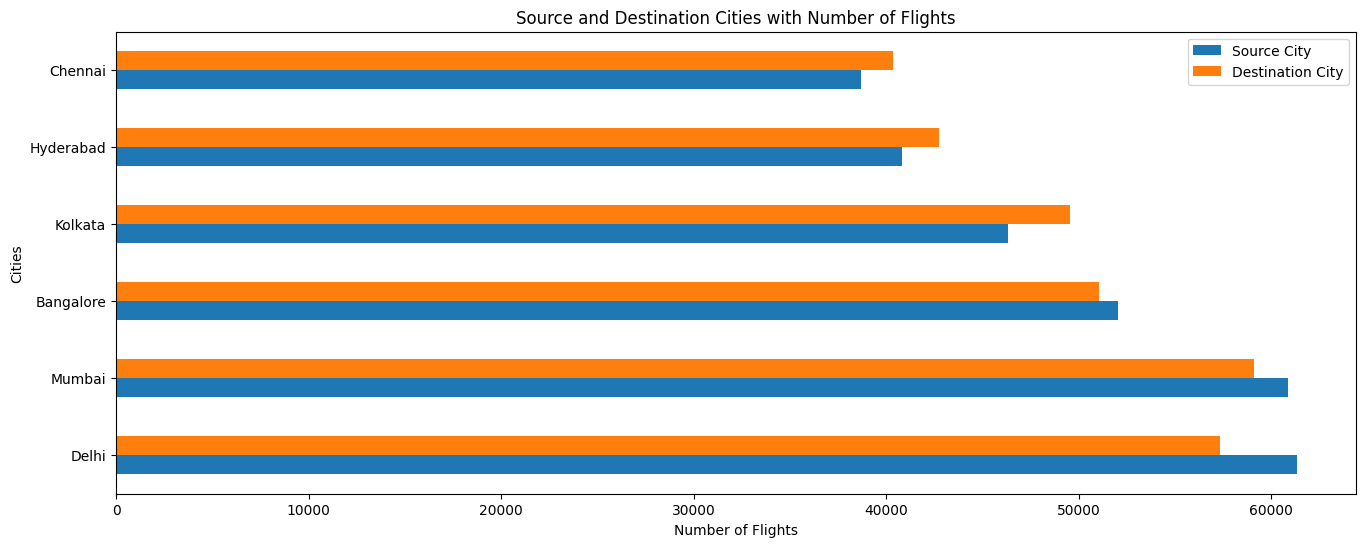

In [38]:
# Combine source and destination city counts

city_counts = pd.concat([data['source_city'].value_counts(), data['destination_city'].value_counts()], axis=1)
city_counts.columns = ['Source City', 'Destination City']

# Plot the combined bar graph
city_counts.plot(kind='barh', figsize=(16, 6))
plt.title("Source and Destination Cities with Number of Flights")
plt.ylabel("Cities")
plt.xlabel("Number of Flights")
plt.show()

**Q.4. Does price varies with airlines ?**

In [39]:
# Grouping the airlines and checking their mean price

data.groupby('airline')['price'].mean()

,price
airline,
AirAsia,4091.072742
Air_India,23507.019112
GO_FIRST,5652.007595
Indigo,5324.216303
SpiceJet,6179.278881
Vistara,30396.536302


/tmp/ipython-input-23773807.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='airline', y='price', palette='rocket', data=data)


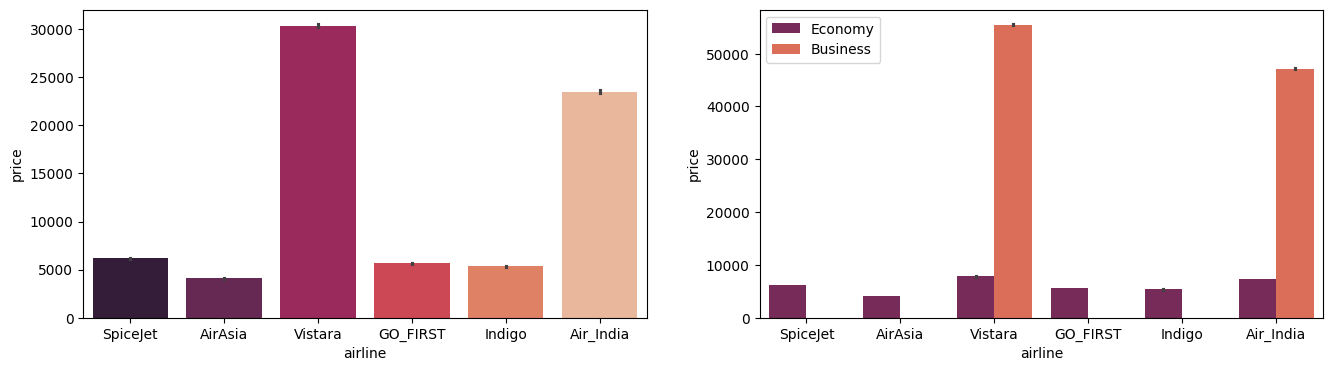

In [48]:
# Drawing a Categorical Plot showing the Mean Ticket Price for each Airline

plt.figure(figsize=(16, 4))

plt.subplot(1, 2, 1)
sns.barplot(x='airline', y='price', palette='rocket', data=data)

plt.subplot(1, 2, 2)
sns.barplot(x='airline', y='price', palette='rocket', data=data, hue='class')
plt.legend(loc='upper left')

plt.show()

**Q.5. Does ticket price change based on the departure time and arrival time**

In [49]:
# Checking the Mean Ticket Price based on the Departure Times

data.groupby('departure_time')['price'].mean()

,price
departure_time,
Afternoon,18179.203331
Early_Morning,20370.676718
Evening,21232.361894
Late_Night,9295.299387
Morning,21630.760254
Night,23062.146808


In [50]:
# Checking the Mean Ticket Price based on the Arrival Times

data.groupby('arrival_time')['price'].mean()

,price
arrival_time,
Afternoon,18494.598993
Early_Morning,14993.139521
Evening,23044.371615
Late_Night,11284.906078
Morning,22231.076098
Night,21586.758341


/tmp/ipython-input-2482898680.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.catplot( x = 'departure_time', y = 'price', kind = 'bar', palette='pastel', data = data )


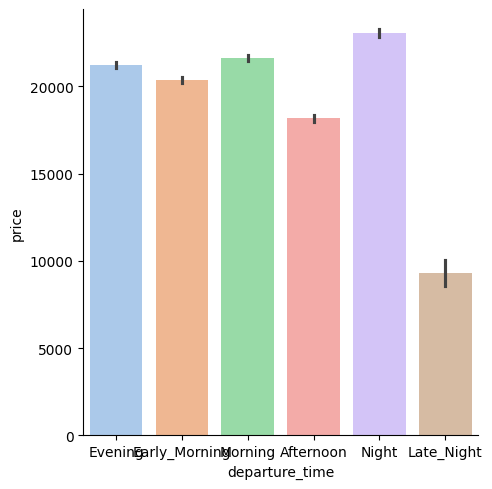

In [54]:
sns.catplot( x = 'departure_time', y = 'price', kind = 'bar', palette='pastel', data = data )

plt.show()

/tmp/ipython-input-2487874569.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.catplot( x = 'arrival_time', y = 'price', kind = 'bar', palette='pastel', data = data )


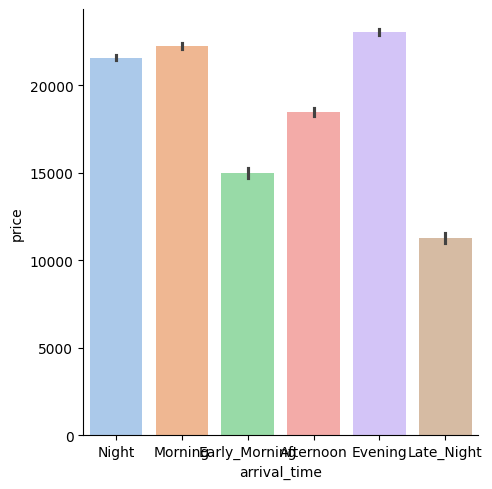

In [56]:
sns.catplot( x = 'arrival_time', y = 'price', kind = 'bar', palette='pastel', data = data )

plt.show()

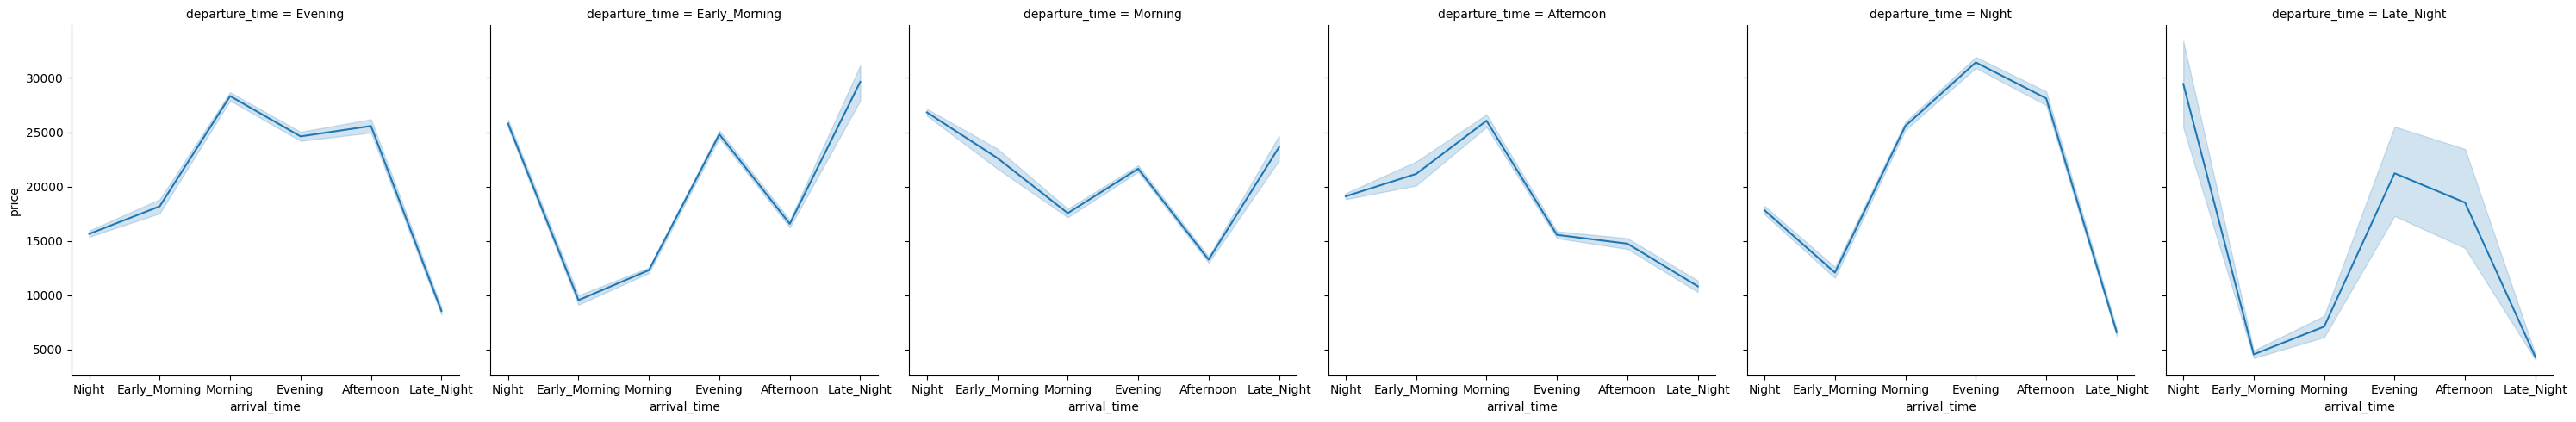

In [57]:
sns.relplot( x = 'arrival_time', y = 'price', data = data, col = 'departure_time', kind = 'line')

plt.show()

**Q.6. How the price changes with change in Source and Destination?**

In [58]:
# Checking the Mean Ticket Price for each Source City

data.groupby('source_city')['price'].mean()

,price
source_city,
Bangalore,21469.460575
Chennai,21995.339871
Delhi,18951.326639
Hyderabad,20155.623879
Kolkata,21746.235679
Mumbai,21483.818839


In [59]:
# Checking the Mean Ticket Price for each Destination City

data.groupby('destination_city')['price'].mean()

,price
destination_city,
Bangalore,21593.955784
Chennai,21953.323969
Delhi,18436.767870
Hyderabad,20427.661284
Kolkata,21959.557556
Mumbai,21372.529469


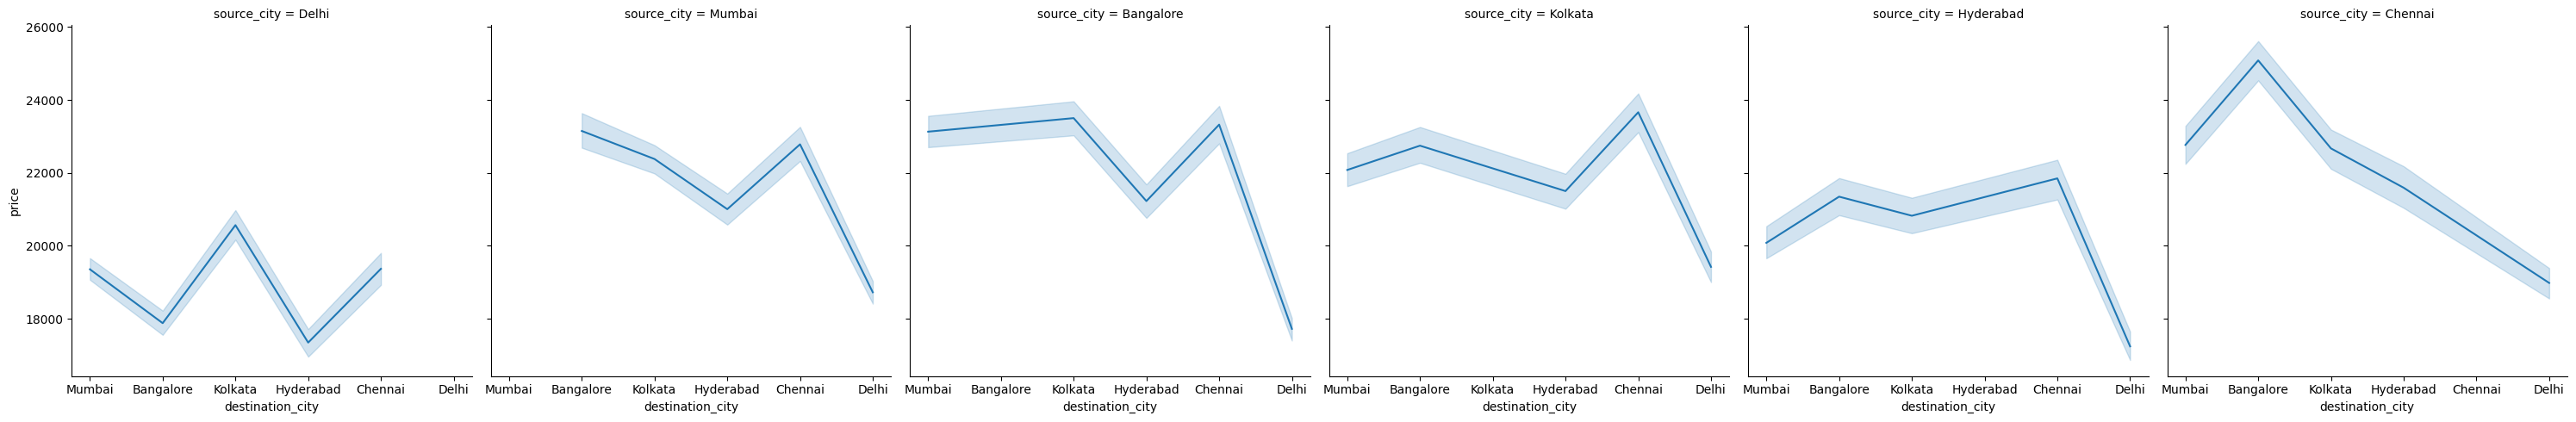

In [60]:
sns.relplot( x = 'destination_city', y = 'price', data = data, col = "source_city", kind = 'line')

plt.show()

**Q.7. How is the price affected when tickets are bought in just 1 or 2 days before departure?**

In [61]:
data['days_left'].nunique()

49

In [62]:
data['days_left'].unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
       35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49])

In [63]:
# Checking the Mean Ticket Price for different days_left

data.groupby('days_left')['price'].mean()

,price
days_left,
1,21591.867151
2,30211.299801
3,28976.083569
4,25730.905653
5,26679.773368
6,24856.493902
7,25588.367351
8,24895.883995
9,25726.246072


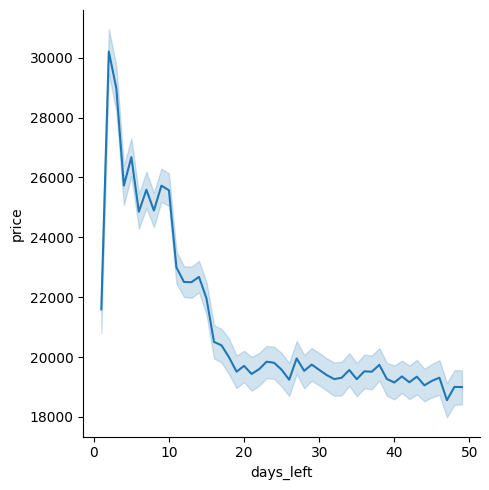

In [64]:
sns.relplot( y='price', x = 'days_left', kind = 'line', data = data )

plt.show()

**Q.8. How does the ticket price vary between Economy and Business class?**

In [65]:
data['class'].unique()

array(['Economy', 'Business'], dtype=object)

In [66]:
# Filtering out the records with Economy class

x = data [ data['class'] == 'Economy' ]

x

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955
...,...,...,...,...,...,...,...,...,...,...,...
206661,Vistara,UK-832,Chennai,Early_Morning,one,Night,Hyderabad,Economy,13.83,49,7697
206662,Vistara,UK-832,Chennai,Early_Morning,one,Night,Hyderabad,Economy,13.83,49,7709
206663,Vistara,UK-826,Chennai,Afternoon,one,Morning,Hyderabad,Economy,20.58,49,8640
206664,Vistara,UK-822,Chennai,Morning,one,Morning,Hyderabad,Economy,23.33,49,8640


In [67]:
# Checking Mean Price for Economy class tickets

x.price.mean()

np.float64(6572.342383362527)

In [68]:
# Filtering out the records with Business class

y = data [ data['class'] == 'Business' ]

y

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
206666,Air_India,AI-868,Delhi,Evening,zero,Evening,Mumbai,Business,2.00,1,25612
206667,Air_India,AI-624,Delhi,Evening,zero,Night,Mumbai,Business,2.25,1,25612
206668,Air_India,AI-531,Delhi,Evening,one,Night,Mumbai,Business,24.75,1,42220
206669,Air_India,AI-839,Delhi,Night,one,Night,Mumbai,Business,26.50,1,44450
206670,Air_India,AI-544,Delhi,Evening,one,Night,Mumbai,Business,6.67,1,46690
...,...,...,...,...,...,...,...,...,...,...,...
300148,Vistara,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,69265
300149,Vistara,UK-826,Chennai,Afternoon,one,Night,Hyderabad,Business,10.42,49,77105
300150,Vistara,UK-832,Chennai,Early_Morning,one,Night,Hyderabad,Business,13.83,49,79099
300151,Vistara,UK-828,Chennai,Early_Morning,one,Evening,Hyderabad,Business,10.00,49,81585


In [69]:
# Checking Mean Price for Business class tickets

y.price.mean()

np.float64(52540.08112357868)

In [73]:
# Create a dataframe with the average prices
avg_price_economy = x.price.mean()
avg_price_business = y.price.mean()

average_prices_df = pd.DataFrame({
    'average price for economy': [avg_price_economy],
    'average price for business': [avg_price_business]
})

display(average_prices_df)

,average price for economy,average price for business
0,6572.342383,52540.081124


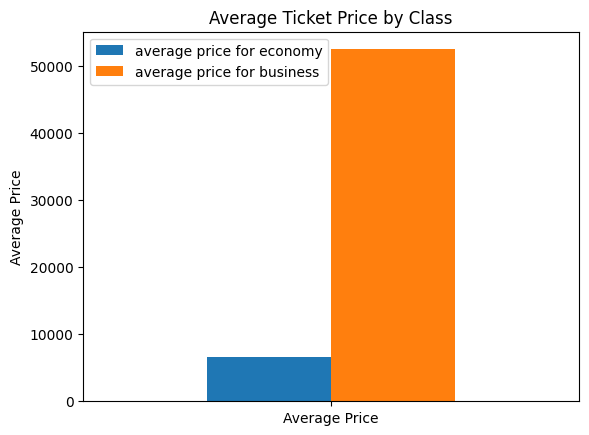

In [80]:
# Create a bar plot of the average prices
average_prices_df.plot(kind='bar')

# Add titles and labels
plt.title('Average Ticket Price by Class')
plt.ylabel('Average Price')
plt.xticks([0], ['Average Price'], rotation=0) # Change x-axis tick label

plt.show()

**Q.9. What will be the Average Price of Vistara airline for a flight from Delhi to Hyderabad in Business Class ?**

In [81]:
# applying filtering based on multiple conditions

new_data = data [(data['airline'] == 'Vistara') & (data['source_city'] == 'Delhi') & (data['destination_city'] == 'Hyderabad')
     & (data['class'] == 'Business')]

In [82]:
new_data

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
219123,Vistara,UK-871,Delhi,Night,zero,Night,Hyderabad,Business,2.33,1,30630
219124,Vistara,UK-879,Delhi,Evening,zero,Evening,Hyderabad,Business,2.25,1,38470
219129,Vistara,UK-955,Delhi,Evening,one,Night,Hyderabad,Business,27.17,1,63513
219130,Vistara,UK-955,Delhi,Evening,one,Afternoon,Hyderabad,Business,18.50,1,65764
219131,Vistara,UK-985,Delhi,Evening,one,Night,Hyderabad,Business,25.08,1,69113
...,...,...,...,...,...,...,...,...,...,...,...
221863,Vistara,UK-963,Delhi,Morning,one,Early_Morning,Hyderabad,Business,23.00,49,53937
221864,Vistara,UK-985,Delhi,Evening,one,Early_Morning,Hyderabad,Business,12.00,49,59537
221865,Vistara,UK-985,Delhi,Evening,one,Afternoon,Hyderabad,Business,16.42,49,59537
221866,Vistara,UK-955,Delhi,Evening,one,Early_Morning,Hyderabad,Business,14.08,49,61889


In [83]:
# Checking the mean price

new_data['price'].mean()

np.float64(47939.840361445786)